In [1]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from sklearn.decomposition import PCA



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *
np.set_printoptions(suppress=True)

Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [58]:
def deveation(df):
    for ind,row in df.iterrows():
        try:
            obstacle_ind = int(np.argwhere(row.ts_distance_from_edge>= -2).max())
        except ValueError:
            continue
        try:
            goal_ind = int(np.argwhere(row.ts_distance_from_edge<= -2).min())
        except ValueError:
            continue
        df.at[ind,'obstacle_ind'] = obstacle_ind
        df.at[ind,'goal_ind'] = goal_ind

        obstacle_basis_start_x, obstacle_basis_start_y = row.ts_head_cen_x_cm[0],row.ts_head_cen_y_cm[0]
        obstacle_basis_end_x, obstacle_basis_end_y = row.ts_head_cen_x_cm[obstacle_ind],row.ts_head_cen_y_cm[obstacle_ind]
        obstacle_basis_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_basis_end_x,obstacle_basis_end_y))
        obstacle_head_cen_x,obstacle_head_cen_y = row.ts_head_cen_x_cm[:obstacle_ind],row.ts_head_cen_y_cm[:obstacle_ind]
        df.at[ind,'obstacle_head_cen_x'] = obstacle_head_cen_x.astype(object)
        df.at[ind,'obstacle_head_cen_y'] = obstacle_head_cen_y.astype(object)
        df.at[ind,'obstacle_basis_start_x'] = obstacle_basis_start_x
        df.at[ind,'obstacle_basis_start_y'] = obstacle_basis_start_y
        df.at[ind,'obstacle_basis_end_x'] = obstacle_basis_end_x
        df.at[ind,'obstacle_basis_end_y'] = obstacle_basis_end_y


        goal_basis_start_x, goal_basis_start_y = row.ts_head_cen_x_cm[goal_ind],row.ts_head_cen_y_cm[goal_ind]
        goal_basis_end_x, goal_basis_end_y = row.ts_head_cen_x_cm[-1],row.ts_head_cen_y_cm[-1]
        goal_basis_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_basis_end_x,goal_basis_end_y))
        goal_head_cen_x,goal_head_cen_y = row.ts_head_cen_x_cm[goal_ind:],row.ts_head_cen_y_cm[goal_ind:]
        df.at[ind,'goal_head_cen_x'] = goal_head_cen_x.astype(object)
        df.at[ind,'goal_head_cen_y'] = goal_head_cen_y.astype(object)
        df.at[ind,'goal_basis_start_x'] = goal_basis_start_x
        df.at[ind,'goal_basis_start_y'] = goal_basis_start_y
        df.at[ind,'goal_basis_end_x'] = goal_basis_end_x
        df.at[ind,'goal_basis_end_y'] = goal_basis_end_y

        obstacle_devations = []
        for i in list(range(len(obstacle_head_cen_x))):
            obstacle_head_cen_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_head_cen_x[i],obstacle_head_cen_y[i]))
            _,dev = angle_between_vectors(obstacle_head_cen_vector,obstacle_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            obstacle_devations.append(dev)
        df.at[ind,'obstacle_devations'] = np.array(obstacle_devations).astype(object)
        
        goal_devations = []
        for i in list(range(len(goal_head_cen_x))):
            goal_head_cen_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_head_cen_x[i],goal_head_cen_y[i]))
            _,dev = angle_between_vectors(goal_head_cen_vector,goal_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            goal_devations.append(dev)
        df.at[ind,'goal_devations'] = np.array(goal_devations).astype(object)


def calculate_vector_between_points(point1, point2):
    """
    Calculate the vector between two (x, y) points.

    Args:
        point1 (tuple or list): The coordinates of the first point (x1, y1).
        point2 (tuple or list): The coordinates of the second point (x2, y2).

    Returns:
        np.ndarray: The vector as a NumPy array [dx, dy].
    """
    x1, y1 = point1
    x2, y2 = point2
    
    dx = x2 - x1
    dy = y2 - y1

    
    vector = np.array([dx, dy])
    
    return vector


def angle_between_vectors(vector1, vector2):
    # Convert input lists to NumPy arrays for vector operations
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vector1, vector2)
    
    # Calculate the magnitudes (norms) of each vector
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    
    # Calculate the cosine of the angle between the vectors
    cosine_angle = dot_product / (magnitude1 * magnitude2)
    
    # Use arccosine to calculate the angle in radians
    angle_radians = np.arccos(cosine_angle)
    
    # Calculate the angle in degrees
    angle_degrees = np.degrees(angle_radians)
    return angle_radians, angle_degrees

In [2]:
F3LILT_TT_df = pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_data_df.h5")

F3LILT_TT_imu_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_imu_data_df.h5")

F3LILT_TT_gaze_df =pd.read_hdf(r"\\goeppert\Vol2\mike\metadata\gaze_shift\data\F3LILT_F3LITT_all_gaze.h5")

In [57]:
ts_calculate_relative_distance(F3LILT_TT_df)


In [59]:
deveation(F3LILT_TT_df)

(array([   13.,   142.,  2179., 24802., 61945.,  1482.,   134.,    25.,
            0.,     2.]),
 array([-498.06007194, -375.06439129, -252.06871064, -129.07302998,
          -6.07734933,  116.91833132,  239.91401198,  362.90969263,
         485.90537329,  608.90105394,  731.89673459]),
 <BarContainer object of 10 artists>)

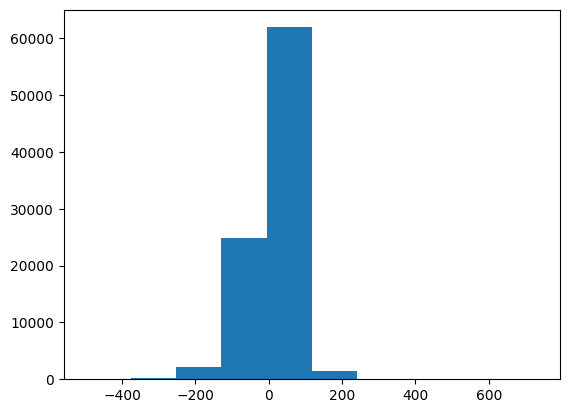

In [9]:
plt.hist(F3LILT_TT_imu_df['dHead'] [0])

In [ ]:

def distance_at_head_turn(df):
    for ind,row in df.iterrows():
        peaks, prop = find_peaks(np.abs(row.head_angle_velocity[:int(row.obstacle_ind)]), width=2,height=(3,20),distance=10)
        print(peaks)
        
        if len(peaks) == 1:
            max_peak = peaks[prop['peak_heights'].argmax()]
            max_vel = prop['peak_heights'].max()
            max_ind = prop['peak_heights'].argmax()
           
            end_movement = int(np.round(prop['right_ips'][prop['peak_heights'].argmax()]))
            start_movement = int(np.round(prop['left_ips'][prop['peak_heights'].argmax()]))
            df.at[ind,'distance_at_head_turn'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'distance_after_head_turn'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][end_movement]
            df.at[ind,'distance_before_head_turn'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][start_movement]
            df.at[ind,'indexs_of_head_turn'] = np.asarray([start_movement,max_peak,end_movement]).astype(object)
            df.at[ind,'head_turn_indexs'] = np.array(peaks).astype(object)
            df.at[ind,'before_head_turn_indexs'] = np.round(prop['left_ips']).astype(int).astype(object)
            df.at[ind,'after_head_turn_indexs'] = np.round(prop['right_ips']).astype(int).astype(object)
            df.at[ind,'angle_at_head_turn'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'angle_after_head_turn'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][end_movement]
            df.at[ind,'angle_before_head_turn'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][start_movement]
            df.at[ind,'num_turn'] = len(peaks)
            df.at[ind,'head_turn_velocity'] = max_vel
            df.at[ind,'angles_at_head_turns'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][max_peak]
            df.at[ind,'angles_at_head_turns_ends'] = row.ts_angle_to_corner[:int(row.obstacle_ind)][end_movement]
            df.at[ind,'distances_at_head_turns'] = row.ts_distance_from_edge[:int(row.obstacle_ind)][max_peak]

In [12]:
F3LILT_TT_imu_df['date'] [0]

'050925'

In [11]:
F3LILT_TT_imu_df['animal'] [0]

'F3LILT'

In [10]:
F3LILT_TT_imu_df['dHead'] [0]

array([nan, nan, nan, ..., 4.541455245526066, nan, nan], dtype=object)

In [16]:
F3LILT_TT_imu_df.columns.to_numpy()

array(['animal', 'date', 'Usegood_reflec', 'spot_count', 'ellipticity',
       'usegood_ellipcalb', 'ellipse', 'scale', 'cam_cent', 'pupil_count',
       'offset', 'ccmax', 'Openephys_time', 'dEye_dps', 'dHead', 'imuT',
       'dGaze', 'eyeT', 'gazeL_event', 'gazeL_idx', 'gazeR_event',
       'gazeR_idx', 'compL_event', 'compL_idx', 'compR_event',
       'compR_idx', 'usegood_eyecalib'], dtype=object)

In [17]:
F3LILT_TT_imu_df['Openephys_time'][0][0]

46572.788723

In [38]:
F3LILT_TT_imu_df['date'][3]

'051225'

In [254]:
date =  F3LILT_TT_imu_df['date'][3]

animal = F3LILT_TT_imu_df['animal'] [3]

df = F3LILT_TT_df[(F3LILT_TT_df['animal']==animal)& (F3LILT_TT_df['date']==date)]

gazeR_event = F3LILT_TT_imu_df['gazeR_event'][3]

gazeL_event = F3LILT_TT_imu_df['gazeL_event'][3]

OpenephysT0 = F3LILT_TT_imu_df['Openephys_time'][3][0]

eyeT = F3LILT_TT_imu_df['eyeT'][3]

dEye_dps = F3LILT_TT_imu_df['dEye_dps'][3]

dHead = F3LILT_TT_imu_df['dHead'][3]

dGaze =  F3LILT_TT_imu_df['dGaze'][3]

timestamps = F3LILT_TT_imu_df['Openephys_time'][3]

In [265]:
F3LILT_TT_imu_df['Openephys_time'][3]

array([50320.705382, 50320.705459, 50320.70551, ..., 51312.764569,
       51312.764595, 51312.764633], dtype=object)

In [264]:
F3LILT_TT_imu_df['Openephys_time'][2]

array([52151.789568, 52151.78967, 52151.789708, ..., 53595.02176,
       53595.021798, 53595.021836], dtype=object)

In [ ]:
flatten_list_of_arrays(df.ts_trial_timestamps.to_numpy())-OpenephysT0)

array([ 12.948915,  12.965427,  12.982362, ..., 972.104768, 972.121408,
       972.138061])

In [262]:
timestamps-OpenephysT0

array([0.0, 7.699999696342275e-05, 0.00012799999967683107, ...,
       992.0591869999989, 992.0592130000005, 992.0592509999988],
      dtype=object)

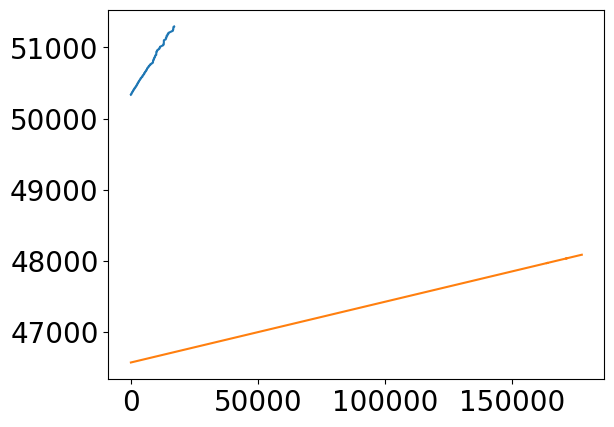

In [269]:
plt.plot(flatten_list_of_arrays(df.ts_trial_timestamps.to_numpy()))
plt.plot(F3LILT_TT_imu_df['Openephys_time'][0])

In [ ]:
flatten_list_of_arrays(cluster_df.ts_trial_timestamps.to_numpy())

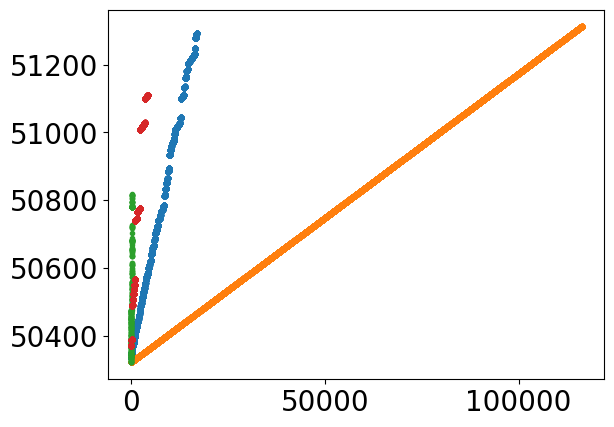

In [382]:
plt.plot(flatten_list_of_arrays(df.ts_trial_timestamps.to_numpy()),'.')
plt.plot(timestamps,'.')
plt.plot(gaze_timestmps,'.')
plt.plot(flatten_list_of_arrays(cluster_df.ts_trial_timestamps.to_numpy()),'.')

In [300]:
flatten_list_of_arrays(cluster_df.ts_trial_timestamps.to_numpy())[-1]

51111.814617

In [299]:
gaze_timestmps[-1]

50817.213849

In [364]:
cluster_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,obstacle_basis_end_x,obstacle_basis_end_y,goal_head_cen_x,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations
315,50361.552921,50371.994560,"[50361.569254, 50361.585433, 50361.602124, 503...","[2469, 2470, 2471, 2472, 2473, 2474, 2475, 247...",30.476414,39.948597,"[0.9806698560714722, 0.982363224029541, 0.9885...",847.33905,41.495216,"[0.9970822930335999, 0.9979604482650757, 0.998...",...,34.375715,23.087403,"[34.039345362788424, 33.70022277747802, 33.357...","[22.944046442766716, 22.84409469499215, 22.787...",34.039345,22.944046,7.058491,23.007060,"[nan, 44.918893142687736, 44.835059167192306, ...","[nan, 16.55597456090671, 13.076502197087152, 9..."
317,50378.647065,50389.330444,"[50378.66112, 50378.677811, 50378.694464, 5037...","[3494, 3495, 3496, 3497, 3498, 3499, 3500, 350...",30.476414,39.948597,"[0.9760379791259766, 0.9830150604248047, 0.980...",847.33905,41.495216,"[0.9940181970596313, 0.9936733245849609, 0.995...",...,34.239576,23.503990,"[33.80632651308561, 33.34088926447257, 32.8443...","[23.49694774692357, 23.507897367649694, 23.524...",33.806327,23.496948,7.231819,24.675956,"[nan, 32.609304518414596, 31.325638088929896, ...","[nan, 1.192665705352704, 0.9183572953897001, 1..."
329,50478.893504,50490.637798,"[50478.897356, 50478.914022, 50478.930662, 504...","[9505, 9506, 9507, 9508, 9509, 9510, 9511, 951...",30.476414,39.948597,"[0.977425217628479, 0.9786858558654785, 0.9782...",847.33905,41.495216,"[0.9973878264427185, 0.9981912970542908, 0.996...",...,35.632129,21.907894,"[35.245684573880006, 34.84339435904852, 34.429...","[21.84646845377036, 21.764523515558633, 21.662...",35.245685,21.846468,6.832126,22.398690,"[nan, 52.77597767052117, 51.90865359009344, 50...","[nan, 12.626822774003925, 13.824247134135849, ..."
331,50496.876608,50507.305907,"[50496.890163, 50496.906739, 50496.924044, 504...","[10584, 10585, 10586, 10587, 10588, 10589, 105...",30.476414,39.948597,"[0.9831269979476929, 0.9807167649269104, 0.970...",847.33905,41.495216,"[0.9968408346176147, 0.9946677684783936, 0.993...",...,36.080160,21.885689,"[35.735154099029785, 35.392296878767624, 35.05...","[21.689486058080323, 21.51031617955451, 21.352...",35.735154,21.689486,6.822169,22.181658,"[nan, 14.678065436283264, 14.631504844803931, ...","[nan, 28.56583362284645, 27.254706656773635, 2..."
333,50513.651212,50523.863462,"[50513.665651, 50513.682329, 50513.699008, 505...","[11590, 11591, 11592, 11593, 11594, 11595, 115...",30.476414,39.948597,"[0.9813659191131592, 0.9786948561668396, 0.975...",847.33905,41.495216,"[0.9939407110214233, 0.991999626159668, 0.9954...",...,35.665248,21.935065,"[35.33054966330879, 34.99486580067093, 34.6531...","[21.761279567197622, 21.599038240120244, 21.45...",35.330550,21.761280,7.039485,22.100275,"[nan, 33.27746450979821, 33.903542472499744, 3...","[nan, 26.481722977784422, 25.183449843516478, ..."
335,50528.295718,50536.955635,"[50528.306828, 50528.323417, 50528.340096, 505...","[12468, 12469, 12470, 12471, 12472, 12473, 124...",30.476414,39.948597,"[0.9815084338188171, 0.9859840273857117, 0.978...",847.33905,41.495216,"[0.9903004169464111, 0.9950673580169678, 0.994...",...,36.015408,21.509860,"[35.615894628761595, 35.217829844919436, 34.82...","[21.45590220043507, 21.42812737193654, 21.4197...",35.615895,21.455902,7.154833,22.988818,"[nan, 54.41609546944599, 53.703509032886345, 5...","[nan, 7.074302180961482, 5.686547023119173, 4...."
337,50541.998156,50550.731660,"[50542.013964, 50542.030681, 50542.04736, 5054...","[13290, 13291, 13292, 13293, 13294, 13295, 132...",30.476414,39.948597,"[0.9763855934143066, 0.9759047627449036, 0.977...",847.33905,41.495216,"[0.9938521385192871, 0.9945853352546692, 0.993...",...,35.523585,22.195740,"[35.089989389217976, 34.632996781810704, 34.16...","[22.153269027160846,

gaze


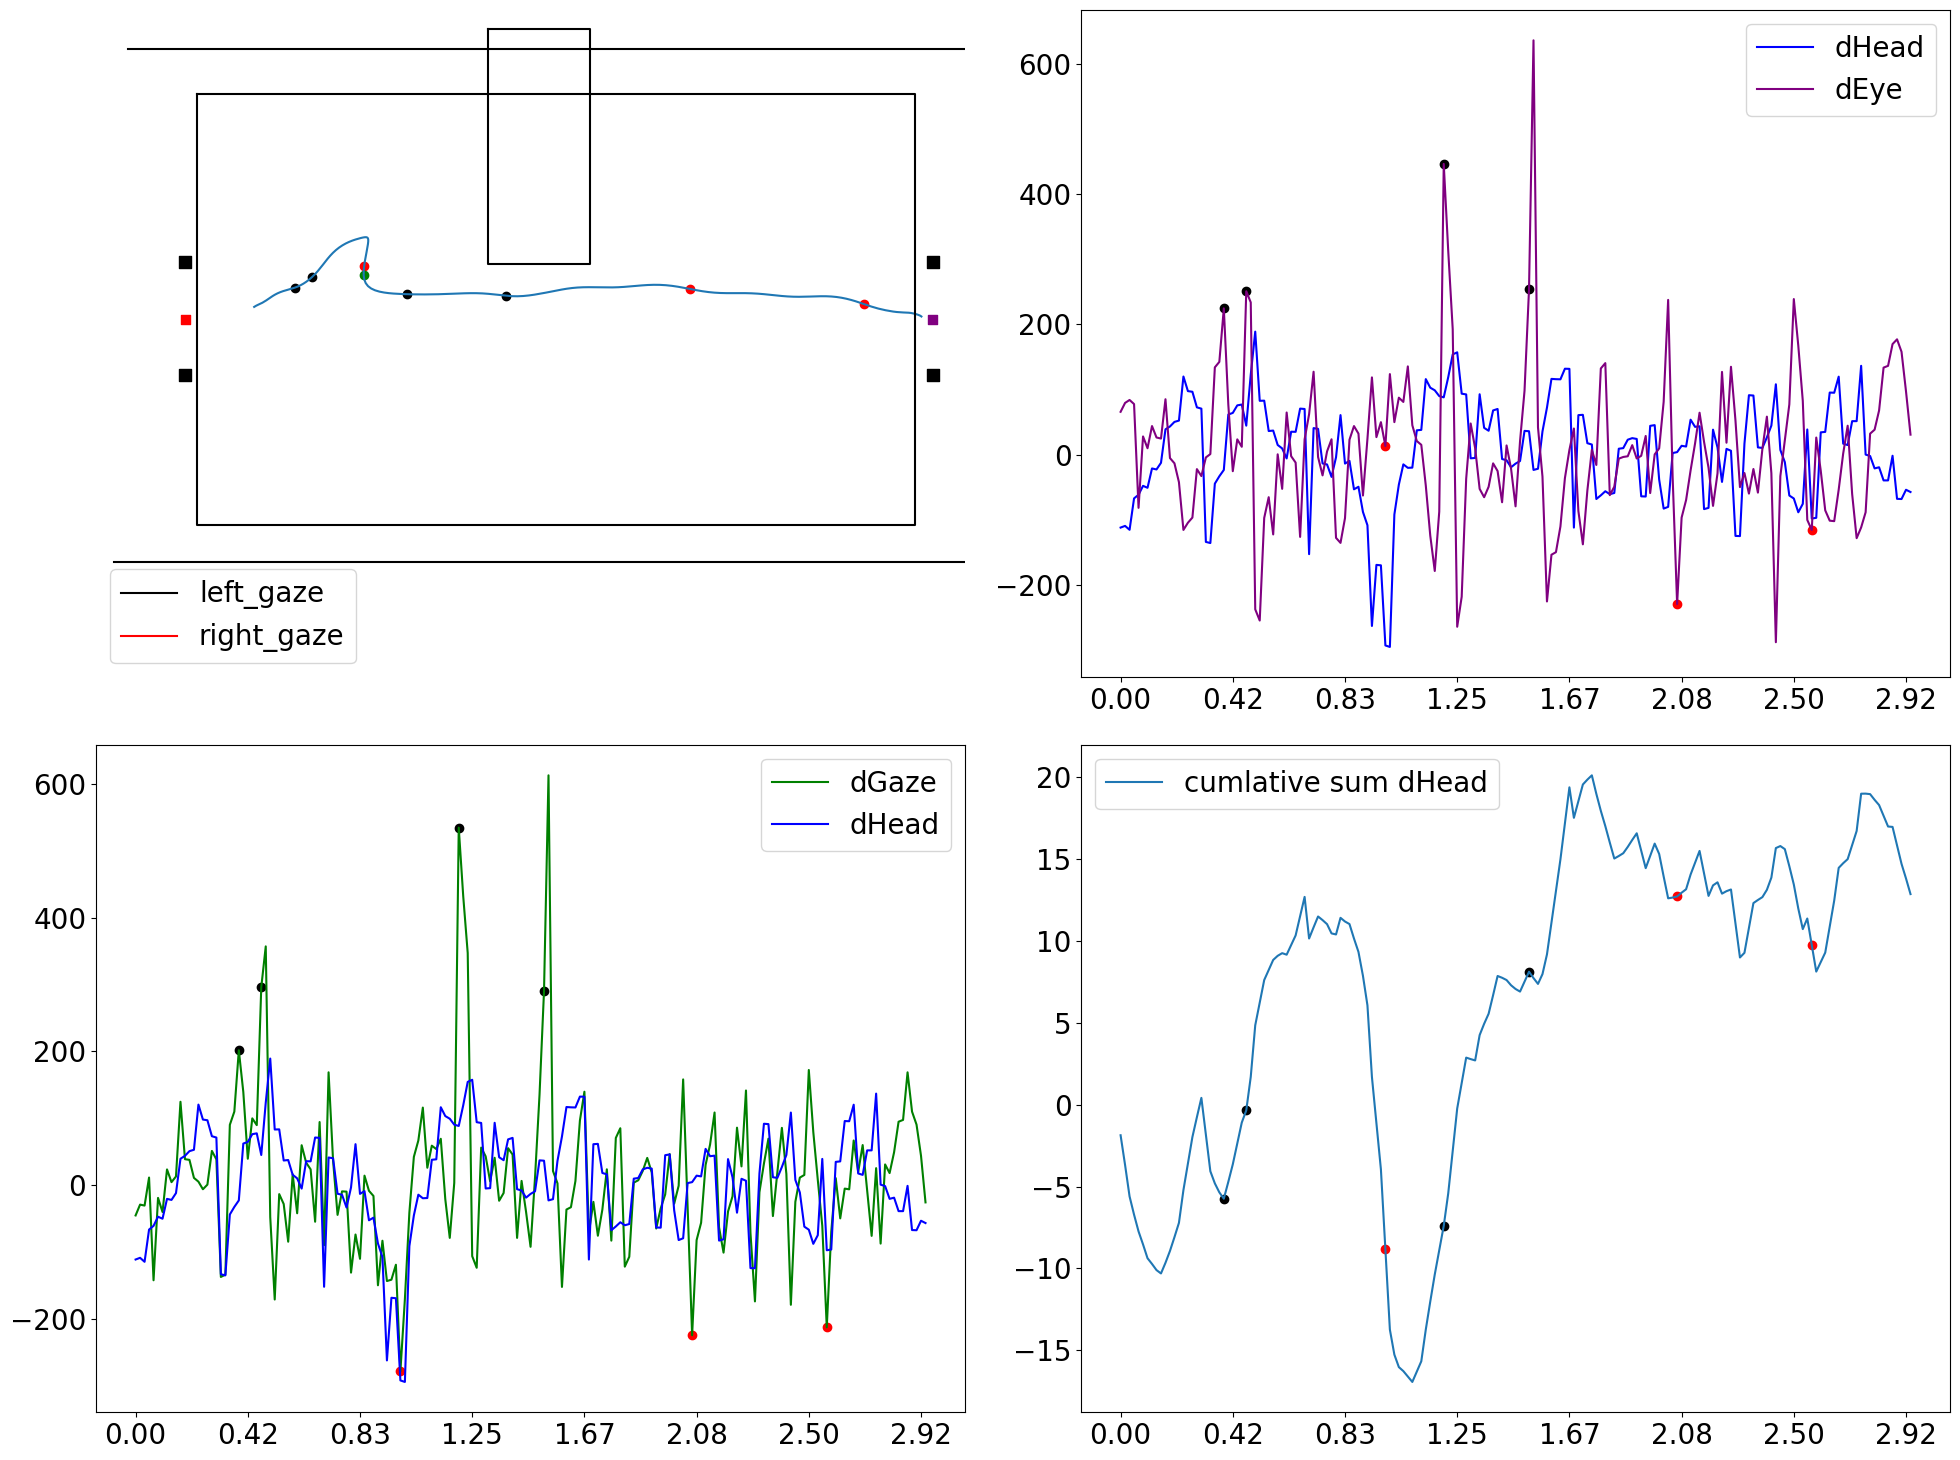

In [402]:

fig,ax_trial = plt.subplots(2,2,figsize=(20, 15))
row =cluster_df.sample(1).T.iloc[:,0]
gaze_data = process_original_plots(row, ax_trial[0,0], gazeR_event, gazeL_event, OpenephysT0,
                                               eyeT=eyeT,dEye_dps=dEye_dps,dHead=dHead,dGaze=dGaze)
            

gazeR_trial_idx = gaze_data['gazeR_trial_idx']
gazeL_trial_idx = gaze_data['gazeL_trial_idx']
dEye_dps_trial = gaze_data['dEye_dps_trial']
dHead_trial = gaze_data['dHead_trial']
dGaze_trial = gaze_data['dGaze_trial']
r_ind = gaze_data['r_ind']
l_ind = gaze_data['l_ind']
ts_trial_vidframes = gaze_data['ts_trial_vidframes']


#ax_trial[0,0].plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)
left_gaze = mlines.Line2D([], [], color='k',
                      markersize=15, label='left_gaze')
right_gaze = mlines.Line2D([], [], color='red',
                      markersize=15, label='right_gaze')
ax_trial[0,0].legend(handles = [left_gaze,right_gaze])
ax_trial[0,1].plot(dHead_trial,c = 'blue')
ax_trial[0,1].plot(dEye_dps_trial,c = 'purple')
ax_trial[0,1].legend(["dHead", "dEye"])
ax_trial[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
ax_trial[1,0].plot(dGaze_trial,c='green')
ax_trial[1,0].plot(dHead_trial,c = 'blue')
ax_trial[1,0].legend(["dGaze","dHead"])
ax_trial[1,0].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
ax_trial[1,1].plot(np.cumsum(dHead_trial)/60)
ax_trial[1,1].legend(['cumlative sum dHead'])
ax_trial[1,1].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
if (r_ind == None) & (l_ind == None):
    print('no gaze')
elif (r_ind != None) & (l_ind != None):
    print('gaze')
    #print(row.ts_head_cen_y_cm[np.array(l_ind)])
    ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)],row.ts_head_cen_y_cm[np.array(l_ind)],c='black')
    ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)],row.ts_head_cen_y_cm[np.array(r_ind)],c='red')
    ax_trial[0,1].scatter(gazeR_trial_idx,dEye_dps_trial[[gazeR_trial_idx]],c ='red')
    ax_trial[0,1].scatter(gazeL_trial_idx,dEye_dps_trial[[gazeL_trial_idx]],c ='black')
    ax_trial[1,0].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
    ax_trial[1,0].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')
elif r_ind == None:
    print('no gaze r')
    ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)],row.ts_head_cen_y_cm[np.array(l_ind)],c='black')
    ax_trial[0,1].scatter(gazeL_trial_idx,dEye_dps_trial[[gazeL_trial_idx]],c ='black')
    ax_trial[1,0].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')
elif l_ind == None:
    print('no gaze 1')
    ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)],row.ts_head_cen_y_cm[np.array(r_ind)],c='red')
    ax_trial[0,1].scatter(gazeR_trial_idx,dEye_dps_trial[[gazeR_trial_idx]],c ='red')
    ax_trial[1,0].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
ax_trial[1,1].scatter(gazeR_trial_idx,np.cumsum(dHead_trial)[[gazeR_trial_idx]]/60,c ='red')
ax_trial[1,1].scatter(gazeL_trial_idx,np.cumsum(dHead_trial)[[gazeL_trial_idx]]/60,c ='black')
peaks, prop = find_peaks(np.abs(dHead_trial[:int(row.obstacle_ind)]), width=1,height=(200,1000))
ax_trial[0,0].scatter(row.ts_head_cen_x_cm[peaks],row.ts_head_cen_y_cm[peaks],c = 'green')
# Adjust layout to prevent overlap
plt.tight_layout()
plt.rcParams['font.size'] = 20  # Set the default font size to 12

In [320]:
peaks

array([ 2, 46], dtype=int64)

In [173]:
prop

{'peak_heights': array([222.15682401, 277.35084285, 217.64342374, 406.53750168,
        337.48345902]),
 'prominences': array([141.38647461, 275.60034138, 141.72236516, 403.64888543,
        303.50947627]),
 'left_bases': array([  0,  37,  69,  69, 116], dtype=int64),
 'right_bases': array([ 37,  69, 111, 128, 128], dtype=int64),
 'widths': array([2.45587833, 2.14671331, 2.11782683, 2.25656206, 2.33745467]),
 'width_heights': array([151.4635867 , 139.55067216, 146.78224116, 204.71305896,
        185.72872088]),
 'left_ips': array([  0.51576243,  40.39030686, 101.62768593, 111.39030426,
        120.23946927]),
 'right_ips': array([  2.97164076,  42.53702017, 103.74551276, 113.64686632,
        122.57692394])}

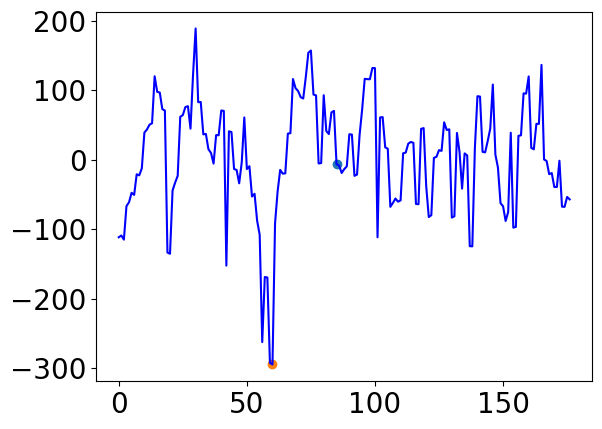

In [404]:
peaks, prop = find_peaks(np.abs(dHead_trial[:int(row.obstacle_ind)]), width=1,height=(200,1000))
plt.plot(dHead_trial,c = 'blue')
plt.scatter(int(row.obstacle_ind),dHead_trial[int(row.obstacle_ind)])
plt.scatter(peaks,dHead_trial[peaks])
#plt.plot(dEye_dps_trial,c = 'red')



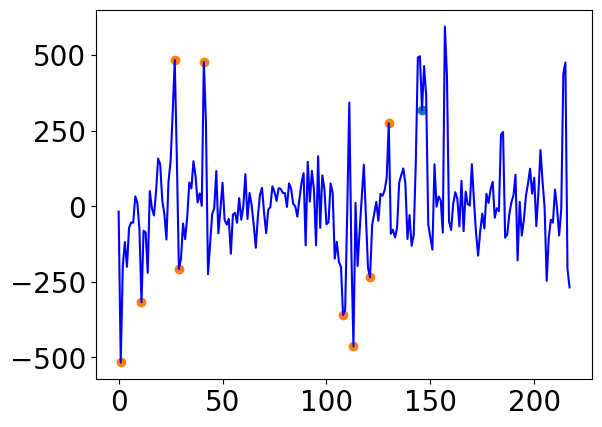

In [165]:
peaks, prop = find_peaks(np.abs(dGaze_trial[:int(row.obstacle_ind)]), width=1,height=(200,1000))
plt.plot(dGaze_trial,c = 'blue')
plt.scatter(int(row.obstacle_ind),dGaze_trial[int(row.obstacle_ind)])
plt.scatter(peaks,dGaze_trial[peaks])

In [184]:
peaks, prop = find_peaks(dHead, width=1,height=(200,1000))

In [164]:
peaks

array([   74,   392,   405,   929,  1251,  1337,  1362,  1374,  1627,
        1637,  2050,  2113,  2303,  2414,  2978,  2985,  3023,  3030,
        3061,  3096,  3100,  3283,  3341,  3358,  3363,  3372,  3378,
        3396,  3436,  3468,  4010,  5113,  5158,  5162,  5203,  5487,
        5493,  5508,  5531,  5551,  6166,  6346,  6358,  6627,  6632,
        6644,  6647,  6705,  6770,  7342,  7532,  7572,  7584,  9162,
        9440, 10524, 11122, 11151, 11587, 12145, 12153, 12407, 12481,
       12919, 13745, 14003, 14016, 14044, 15046, 15152, 15197, 15412,
       15456, 15463, 15471, 15617, 15681, 15917, 15929, 15936, 15946,
       15969, 16782, 17256, 17698, 17708, 17712, 17729, 17831, 17972,
       17998, 18008, 18047, 20202, 20320, 20430, 20729, 21354, 21440,
       21898, 21971, 21983, 21999, 22906, 23909, 25539, 25922, 25975,
       26061, 27244, 27255, 27739, 27816, 27869, 29442, 29669, 30576,
       30817, 30820, 32452, 32840, 33847, 33884, 34022, 34232, 34260,
       36832, 36994,

In [ ]:
plt.plot(calculate_angular_velocity(dHead_trial.astype(float),60))

In [95]:
peaks

array([46, 65], dtype=int64)

In [97]:
len(dHead_trial)

133

In [98]:
len(row.ts_head_cen_x_cm)

134

In [104]:
np.nanmax(dHead)

840.9369865365389

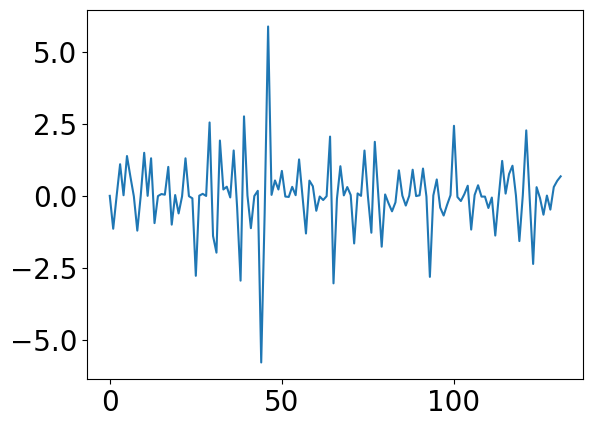

In [94]:


peaks, prop = find_peaks(np.abs(calculate_angular_velocity(dHead_trial.astype(float),1)),height=(3,20),distance=10)
plt.plot(calculate_angular_velocity(dHead_trial.astype(float),1))

In [84]:
def angular_velocity_head_whole_trial(df):
    for ind,row in df.iterrows():
        #filtered_head_angle = gaussian_filter(row.head_angle.astype(float),2)
        head_angle_velocity = calculate_angular_velocity(row.head_angle.astype(float),60).astype(object)
        df.at[ind,'head_angle_velocity_whole_trial'] = head_angle_velocity
        


def calculate_angular_velocity(angles, frame_rate):
    # Convert angles to radians if they are given in degrees
    angles = np.radians(angles)

    # Calculate angular velocity using NumPy's array operations
    angular_displacements = np.diff(angles)
    angular_velocities = angular_displacements / (1 / frame_rate)
    np.angle(angular_velocities.astype(float))
    return angular_velocities


In [ ]:
def deveation(df):
    for ind,row in df.iterrows():
        try:
            obstacle_ind = int(np.argwhere(row.ts_distance_from_edge>= -2).max())
        except ValueError:
            continue
        try:
            goal_ind = int(np.argwhere(row.ts_distance_from_edge<= -2).min())
        except ValueError:
            continue
        df.at[ind,'obstacle_ind'] = obstacle_ind
        df.at[ind,'goal_ind'] = goal_ind

        obstacle_basis_start_x, obstacle_basis_start_y = row.ts_head_cen_x_cm[0],row.ts_head_cen_y_cm[0]
        obstacle_basis_end_x, obstacle_basis_end_y = row.ts_head_cen_x_cm[obstacle_ind],row.ts_head_cen_y_cm[obstacle_ind]
        obstacle_basis_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_basis_end_x,obstacle_basis_end_y))
        obstacle_head_cen_x,obstacle_head_cen_y = row.ts_head_cen_x_cm[:obstacle_ind],row.ts_head_cen_y_cm[:obstacle_ind]
        df.at[ind,'obstacle_head_cen_x'] = obstacle_head_cen_x.astype(object)
        df.at[ind,'obstacle_head_cen_y'] = obstacle_head_cen_y.astype(object)
        df.at[ind,'obstacle_basis_start_x'] = obstacle_basis_start_x
        df.at[ind,'obstacle_basis_start_y'] = obstacle_basis_start_y
        df.at[ind,'obstacle_basis_end_x'] = obstacle_basis_end_x
        df.at[ind,'obstacle_basis_end_y'] = obstacle_basis_end_y


        goal_basis_start_x, goal_basis_start_y = row.ts_head_cen_x_cm[goal_ind],row.ts_head_cen_y_cm[goal_ind]
        goal_basis_end_x, goal_basis_end_y = row.ts_head_cen_x_cm[-1],row.ts_head_cen_y_cm[-1]
        goal_basis_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_basis_end_x,goal_basis_end_y))
        goal_head_cen_x,goal_head_cen_y = row.ts_head_cen_x_cm[goal_ind:],row.ts_head_cen_y_cm[goal_ind:]
        df.at[ind,'goal_head_cen_x'] = goal_head_cen_x.astype(object)
        df.at[ind,'goal_head_cen_y'] = goal_head_cen_y.astype(object)
        df.at[ind,'goal_basis_start_x'] = goal_basis_start_x
        df.at[ind,'goal_basis_start_y'] = goal_basis_start_y
        df.at[ind,'goal_basis_end_x'] = goal_basis_end_x
        df.at[ind,'goal_basis_end_y'] = goal_basis_end_y

        obstacle_devations = []
        for i in list(range(len(obstacle_head_cen_x))):
            obstacle_head_cen_vector = calculate_vector_between_points((obstacle_basis_start_x,obstacle_basis_start_y),(obstacle_head_cen_x[i],obstacle_head_cen_y[i]))
            _,dev = angle_between_vectors(obstacle_head_cen_vector,obstacle_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            obstacle_devations.append(dev)
        df.at[ind,'obstacle_devations'] = np.array(obstacle_devations).astype(object)
        
        goal_devations = []
        for i in list(range(len(goal_head_cen_x))):
            goal_head_cen_vector = calculate_vector_between_points((goal_basis_start_x,goal_basis_start_y),(goal_head_cen_x[i],goal_head_cen_y[i]))
            _,dev = angle_between_vectors(goal_head_cen_vector,goal_basis_vector)
            #devations.append(dev) 
            #dev = calculate_angle((head_cen_x[i],head_cen_y[i]),(origin_x,origin_y),(end_x,end_y))
            goal_devations.append(dev)
        df.at[ind,'goal_devations'] = np.array(goal_devations).astype(object)


def calculate_vector_between_points(point1, point2):
    """
    Calculate the vector between two (x, y) points.

    Args:
        point1 (tuple or list): The coordinates of the first point (x1, y1).
        point2 (tuple or list): The coordinates of the second point (x2, y2).

    Returns:
        np.ndarray: The vector as a NumPy array [dx, dy].
    """
    x1, y1 = point1
    x2, y2 = point2
    
    dx = x2 - x1
    dy = y2 - y1

    
    vector = np.array([dx, dy])
    
    return vector


def angle_between_vectors(vector1, vector2):
    # Convert input lists to NumPy arrays for vector operations
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vector1, vector2)
    
    # Calculate the magnitudes (norms) of each vector
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    
    # Calculate the cosine of the angle between the vectors
    cosine_angle = dot_product / (magnitude1 * magnitude2)
    
    # Use arccosine to calculate the angle in radians
    angle_radians = np.arccos(cosine_angle)
    
    # Calculate the angle in degrees
    angle_degrees = np.degrees(angle_radians)
    return angle_radians, angle_degrees


In [ ]:
def calculate_vector_between_points(point1, point2):
    """
    Calculate the vector between two (x, y) points.

    Args:
        point1 (tuple or list): The coordinates of the first point (x1, y1).
        point2 (tuple or list): The coordinates of the second point (x2, y2).

    Returns:
        np.ndarray: The vector as a NumPy array [dx, dy].
    """
    x1, y1 = point1
    x2, y2 = point2
    
    dx = x2 - x1
    dy = y2 - y1

    
    vector = np.array([dx, dy])
    
    return vector


def angle_between_vectors(vector1, vector2):
    # Convert input lists to NumPy arrays for vector operations
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)
    
    # Calculate the dot product of the two vectors
    dot_product = np.dot(vector1, vector2)
    
    # Calculate the magnitudes (norms) of each vector
    magnitude1 = np.linalg.norm(vector1)
    magnitude2 = np.linalg.norm(vector2)
    
    # Calculate the cosine of the angle between the vectors
    cosine_angle = dot_product / (magnitude1 * magnitude2)
    
    # Use arccosine to calculate the angle in radians
    angle_radians = np.arccos(cosine_angle)
    
    # Calculate the angle in degrees
    angle_degrees = np.degrees(angle_radians)
    return angle_radians, angle_degrees


In [279]:
def extract_headmovement_windows_df(dEye, dHead, dGaze, timestamps, window_left, window_right, animal, date, normalize=True):
    """
    Extract head movement windows into a 3D array (n_movements, 2 signals, window_samples).
    Automatically removes windows with all-zero signals.
    
    Parameters:
    - dEye, dHead, dGaze: 1D time series arrays
    - peak_indices: Indices of peak head movements (from find_peaks)
    - timestamps: Timestamps corresponding to the signal
    - window_left, window_right: Samples to include around peak
    - animal: Animal identifier
    - date: Date of recording
    - normalize: Scale each window to [-1, 1] (default: True)
    
    Returns:
    - output: 3D numpy array of raw windows (n_movements, 2, window_size)
    - output_norm: 3D numpy array of normalized windows (n_movements, 2, window_size)
    - metadata: pandas DataFrame with metadata for each head movement
    """
    dEye = np.asarray(dEye).astype(float)
    dHead = np.asarray(dHead).astype(float)
    dGaze = np.asarray(dGaze).astype(float)
    peak_indices,_ = find_peaks(np.abs(dHead), width=1,height=(200,1000))
    
    if len(dEye) != len(dHead) or len(dEye) != len(dGaze):
        raise ValueError("dEye, dHead, and dGaze must have the same length")
    
    window_size = window_left + window_right + 1
    
    # Initialize lists to store valid windows and metadata
    valid_windows = []
    valid_windows_norm = []
    metadata_list = []
    
    for i, peak_idx in enumerate(peak_indices):
        start = peak_idx - window_left
        end = peak_idx + window_right + 1
        
        # Skip out-of-bounds windows
        if start < 0 or end > len(dEye):
            continue
        
        # Extract windows
        eye_win = dEye[start:end]
        head_win = dHead[start:end]
        gaze_value = dGaze[peak_idx]  # Get dGaze value at peak point
        
        # Skip NaN-containing windows
        if np.isnan(eye_win).any() or np.isnan(head_win).any() or np.isnan(gaze_value):
            continue
        
        # Skip all-zero windows
        if np.all(eye_win == 0) or np.all(head_win == 0):
            continue
        
        # Determine movement direction based on head velocity sign at peak
        movement_direction = 'left' if head_win[window_left] >= 0 else 'right'
        
        # Normalize if required
        if normalize:
            def norm(x):
                x_min, x_max = x.min(), x.max()
                if x_max > x_min:
                    return 2 * ((x - x_min) / (x_max - x_min)) - 1
                return x
            norm_eye_win = norm(eye_win)
            norm_head_win = norm(head_win)
        else:
            norm_eye_win = eye_win
            norm_head_win = head_win
        
        # Store valid windows
        if dHead[peak_idx] > 0:
            valid_windows.append([eye_win, head_win])
            valid_windows_norm.append([norm_eye_win, norm_head_win])
        else:
            valid_windows.append([(eye_win*-1), (head_win*-1)])
            valid_windows_norm.append([(norm_eye_win*-1), (norm_head_win*-1)])

        
        # Add metadata
        metadata_list.append({
            'animal': animal,
            'date': date,
            'peak_index': peak_idx,
            'timestamp': timestamps[peak_idx] if timestamps is not None else None,
            'window_left': window_left,
            'window_right': window_right,
            'window_size': window_size,
            'has_nan': False,
            'is_zero': False,
            'movement_direction': movement_direction,
            'peak_head_velocity': head_win[window_left],  # Head velocity at peak
            'dGaze_value': gaze_value,
            'peak_eye_velocity': eye_win[window_left]   # Eye velocity at peak
        })
    
    # Convert to numpy arrays if we have valid data
    if valid_windows:
        output = np.stack([np.stack(w, axis=0) for w in valid_windows])
        output_norm = np.stack([np.stack(w, axis=0) for w in valid_windows_norm])
    else:
        output = np.empty((0, 2, window_size))
        output_norm = np.empty((0, 2, window_size))
    
    # Create metadata DataFrame
    metadata = pd.DataFrame(metadata_list)
    
    return output, output_norm, metadata

In [295]:
timestamps[74]

50321.252096

In [294]:
metadata

,animal,date,peak_index,timestamp,window_left,window_right,window_size,has_nan,is_zero,movement_direction,peak_head_velocity,dGaze_value,peak_eye_velocity,cluster
0,F3LILT,051225,74,50321.252096,10,10,21,False,False,left,299.171205,518.312339,219.141134,2
1,F3LILT,051225,293,50323.163609,10,10,21,False,False,right,-425.792631,-345.970058,79.822573,1
2,F3LILT,051225,299,50323.163814,10,10,21,False,False,right,-206.408913,-62.293198,144.115716,0
3,F3LILT,051225,305,50323.299968,10,10,21,False,False,right,-267.155577,-265.003136,2.152440,2
4,F3LILT,051225,331,50323.438809,10,10,21,False,False,right,-211.114953,-146.285391,64.829562,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,F3LILT,051225,58085,50816.393369,10,10,21,False,False,right,-222.502366,-207.326360,15.176006,0
390,F3LILT,051225,58107,50816.530188,10,10,21,False,False,right,-359.103172,-186.702766,172.400406,0
391,F3LILT,051225,58116,50816.666534,10,10,21,False,False,right,-208.775365,-139.972280,68.803085,2
392,F3LILT,051225,58122,50816.666739,10,10,21,False,False,right,-261.034023,-27.056172,233.977851,0


In [280]:
output, output_norm, metadata = extract_headmovement_windows_df(dEye_dps, dHead, dGaze, timestamps, 10, 10, animal, date, normalize=True)

In [281]:
output.shape

(394, 2, 21)

In [186]:
output.shape[0]

149

In [282]:
n_gazes = output.shape[0]
flattened_data = output.reshape(n_gazes, -1)
norm_flattened_data = output_norm.reshape(n_gazes, -1)


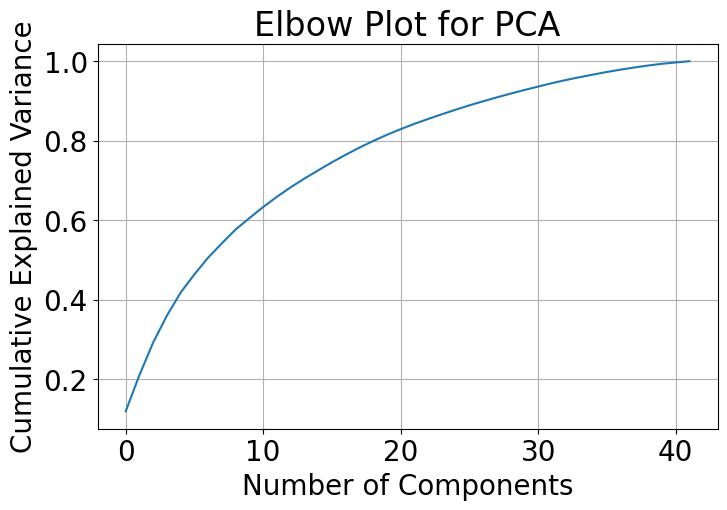

In [283]:
pca = PCA().fit(norm_flattened_data)

# Create elbow plot
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Plot for PCA')
plt.grid()
plt.show()

In [284]:
pca = PCA(n_components=3) # Keep 95% of variance (adjust as needed)
pca_data = pca.fit_transform(norm_flattened_data)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Reduced dimensions: {pca_data.shape}") 

Explained variance ratio: [0.11909184 0.09113825 0.08209501]
Reduced dimensions: (394, 3)


In [285]:
from sklearn.cluster import KMeans

n_clusters = 3#4 # Choose based on your data (e.g., elbow method)
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(pca_data)

print("Cluster labels:", clusters)  # Array of cluster indices (0, 1, 2, ...)

Cluster labels: [2 1 0 2 1 0 2 2 0 2 0 0 1 0 2 2 0 2 2 2 1 2 0 2 2 0 1 0 0 2 0 1 0 2 0 0 2
 2 0 0 2 1 1 0 2 1 0 0 0 0 1 0 0 0 1 0 1 0 0 2 2 1 2 1 0 0 0 1 0 1 0 2 0 0
 0 1 0 2 1 0 1 2 0 1 0 1 0 1 1 0 1 0 2 2 0 0 0 0 0 0 0 0 0 2 1 0 0 1 0 2 0
 1 2 2 2 2 1 2 2 2 2 1 0 2 0 0 1 1 0 0 2 1 2 2 1 0 2 0 1 2 1 1 2 0 1 0 0 2
 2 2 0 2 1 1 0 0 1 0 0 0 1 0 2 2 2 0 0 0 1 0 1 0 2 2 2 0 0 0 0 1 2 1 1 0 0
 2 1 0 0 2 2 2 2 0 2 1 0 0 2 0 2 1 1 0 0 2 1 2 1 0 1 2 1 0 0 1 2 1 0 1 1 0
 0 1 0 0 2 2 0 1 1 0 0 0 0 0 0 1 2 0 0 2 1 1 0 0 1 0 1 2 0 0 1 2 1 0 1 1 0
 1 1 2 0 0 2 0 0 0 0 2 2 2 0 0 2 0 1 2 1 1 2 1 0 1 0 0 0 0 0 1 2 1 1 1 0 0
 1 0 0 0 2 2 2 1 0 0 1 2 2 1 0 0 0 0 0 0 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 0 2 1 1 0 0 0 0 0 1 1 2 2 1 1 2 2 2 2 2 2 0 2 2 0 1 2 2 0
 2 0 0 1 1 0 1 0 2 2 1 2 0 0 0 2 2 2 1 0 0 2 0 2]


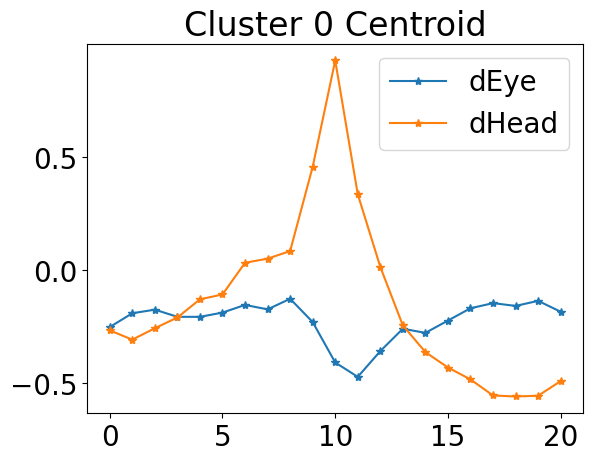

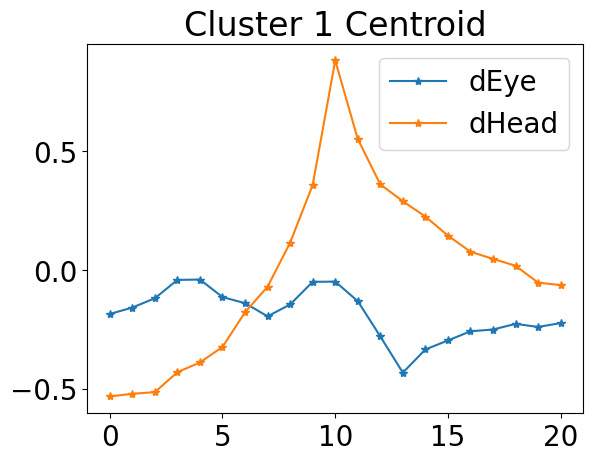

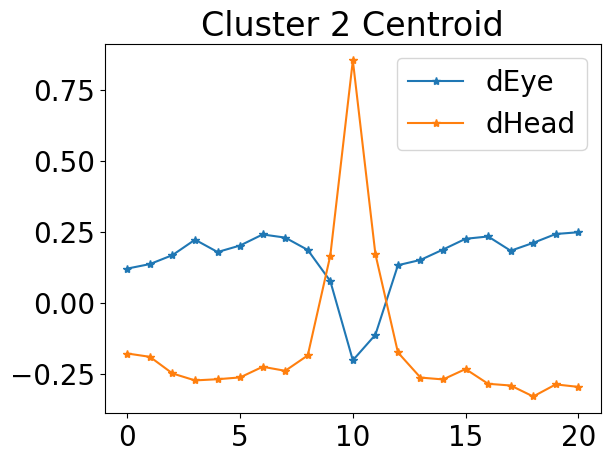

In [286]:
# Get centroids in PCA space
centroids = kmeans.cluster_centers_

# Inverse transform to original feature space
centroids_original = pca.inverse_transform(centroids)
#centroids_original = scaler.inverse_transform(centroids_original)
centroids_original = centroids_original.reshape(n_clusters, 2, -1)  # (n_clusters, 2, window_size)

# Plot centroid windows
for cluster in range(n_clusters):
    plt.figure()
    plt.plot(centroids_original[cluster, 0, :], '-*',label="dEye")
    plt.plot(centroids_original[cluster, 1, :], '-*',label="dHead")
    plt.title(f"Cluster {cluster} Centroid")
    plt.legend()
    #plt.ylim(-.5,.5)
    plt.show()

In [287]:
metadata['cluster'] = clusters

In [224]:
trial_gaze_idx

[4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148]

In [223]:
trial_gaze_idx, trial_indx = find_event_frames(flatten_list_of_arrays(df.ts_trial_timestamps.to_numpy()),gaze_timestmps)

In [201]:
flatten_list_of_arrays(df.ts_trial_timestamps.to_numpy())

array([50333.654297, 50333.670809, 50333.687744, ..., 51292.81015 ,
       51292.82679 , 51292.843443])

In [ ]:
df

In [288]:
metadata

,animal,date,peak_index,timestamp,window_left,window_right,window_size,has_nan,is_zero,movement_direction,peak_head_velocity,dGaze_value,peak_eye_velocity,cluster
0,F3LILT,051225,74,50321.252096,10,10,21,False,False,left,299.171205,518.312339,219.141134,2
1,F3LILT,051225,293,50323.163609,10,10,21,False,False,right,-425.792631,-345.970058,79.822573,1
2,F3LILT,051225,299,50323.163814,10,10,21,False,False,right,-206.408913,-62.293198,144.115716,0
3,F3LILT,051225,305,50323.299968,10,10,21,False,False,right,-267.155577,-265.003136,2.152440,2
4,F3LILT,051225,331,50323.438809,10,10,21,False,False,right,-211.114953,-146.285391,64.829562,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,F3LILT,051225,58085,50816.393369,10,10,21,False,False,right,-222.502366,-207.326360,15.176006,0
390,F3LILT,051225,58107,50816.530188,10,10,21,False,False,right,-359.103172,-186.702766,172.400406,0
391,F3LILT,051225,58116,50816.666534,10,10,21,False,False,right,-208.775365,-139.972280,68.803085,2
392,F3LILT,051225,58122,50816.666739,10,10,21,False,False,right,-261.034023,-27.056172,233.977851,0


In [ ]:
cluster_groups = {}
for cluster_id in np.unique(clusters):
    cluster_groups[cluster_id] = flattened_data[clusters == cluster_id]

# Example: Access all samples in Cluster 0
print("Cluster 0 shape:", cluster_groups[2].shape)  # (n_samples_in_cluster, 2 * window_size)
norm_cluster_groups = {}
for cluster_id in np.unique(clusters):
    norm_cluster_groups[cluster_id] = norm_flattened_data[clusters == cluster_id]

# Example: Access all samples in Cluster 0
print("Cluster 0 shape:", cluster_groups[2].shape)  # (n_samples_in_cluster, 2 * window_size)

Cluster 0 shape: (35, 42)
Cluster 0 shape: (35, 42)


In [207]:
print("Cluster 0 shape:", cluster_groups[2].shape)

Cluster 0 shape: (60, 42)


In [209]:
gaze_timestmps= metadata['timestamp'].to_numpy()
find_event_frames(row.ts_trial_timestamps,gaze_timestmps)

([105, 106], [91, 205])

In [216]:
find_event_frames(row.ts_trial_timestamps,gaze_timestmps)

(None, None)

In [226]:
cluster_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,obstacle_basis_end_x,obstacle_basis_end_y,goal_head_cen_x,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations
315,50361.552921,50371.994560,"[50361.569254, 50361.585433, 50361.602124, 503...","[2469, 2470, 2471, 2472, 2473, 2474, 2475, 247...",30.476414,39.948597,"[0.9806698560714722, 0.982363224029541, 0.9885...",847.33905,41.495216,"[0.9970822930335999, 0.9979604482650757, 0.998...",...,34.375715,23.087403,"[34.039345362788424, 33.70022277747802, 33.357...","[22.944046442766716, 22.84409469499215, 22.787...",34.039345,22.944046,7.058491,23.007060,"[nan, 44.918893142687736, 44.835059167192306, ...","[nan, 16.55597456090671, 13.076502197087152, 9..."
317,50378.647065,50389.330444,"[50378.66112, 50378.677811, 50378.694464, 5037...","[3494, 3495, 3496, 3497, 3498, 3499, 3500, 350...",30.476414,39.948597,"[0.9760379791259766, 0.9830150604248047, 0.980...",847.33905,41.495216,"[0.9940181970596313, 0.9936733245849609, 0.995...",...,34.239576,23.503990,"[33.80632651308561, 33.34088926447257, 32.8443...","[23.49694774692357, 23.507897367649694, 23.524...",33.806327,23.496948,7.231819,24.675956,"[nan, 32.609304518414596, 31.325638088929896, ...","[nan, 1.192665705352704, 0.9183572953897001, 1..."
329,50478.893504,50490.637798,"[50478.897356, 50478.914022, 50478.930662, 504...","[9505, 9506, 9507, 9508, 9509, 9510, 9511, 951...",30.476414,39.948597,"[0.977425217628479, 0.9786858558654785, 0.9782...",847.33905,41.495216,"[0.9973878264427185, 0.9981912970542908, 0.996...",...,35.632129,21.907894,"[35.245684573880006, 34.84339435904852, 34.429...","[21.84646845377036, 21.764523515558633, 21.662...",35.245685,21.846468,6.832126,22.398690,"[nan, 52.77597767052117, 51.90865359009344, 50...","[nan, 12.626822774003925, 13.824247134135849, ..."
331,50496.876608,50507.305907,"[50496.890163, 50496.906739, 50496.924044, 504...","[10584, 10585, 10586, 10587, 10588, 10589, 105...",30.476414,39.948597,"[0.9831269979476929, 0.9807167649269104, 0.970...",847.33905,41.495216,"[0.9968408346176147, 0.9946677684783936, 0.993...",...,36.080160,21.885689,"[35.735154099029785, 35.392296878767624, 35.05...","[21.689486058080323, 21.51031617955451, 21.352...",35.735154,21.689486,6.822169,22.181658,"[nan, 14.678065436283264, 14.631504844803931, ...","[nan, 28.56583362284645, 27.254706656773635, 2..."
333,50513.651212,50523.863462,"[50513.665651, 50513.682329, 50513.699008, 505...","[11590, 11591, 11592, 11593, 11594, 11595, 115...",30.476414,39.948597,"[0.9813659191131592, 0.9786948561668396, 0.975...",847.33905,41.495216,"[0.9939407110214233, 0.991999626159668, 0.9954...",...,35.665248,21.935065,"[35.33054966330879, 34.99486580067093, 34.6531...","[21.761279567197622, 21.599038240120244, 21.45...",35.330550,21.761280,7.039485,22.100275,"[nan, 33.27746450979821, 33.903542472499744, 3...","[nan, 26.481722977784422, 25.183449843516478, ..."
335,50528.295718,50536.955635,"[50528.306828, 50528.323417, 50528.340096, 505...","[12468, 12469, 12470, 12471, 12472, 12473, 124...",30.476414,39.948597,"[0.9815084338188171, 0.9859840273857117, 0.978...",847.33905,41.495216,"[0.9903004169464111, 0.9950673580169678, 0.994...",...,36.015408,21.509860,"[35.615894628761595, 35.217829844919436, 34.82...","[21.45590220043507, 21.42812737193654, 21.4197...",35.615895,21.455902,7.154833,22.988818,"[nan, 54.41609546944599, 53.703509032886345, 5...","[nan, 7.074302180961482, 5.686547023119173, 4...."
337,50541.998156,50550.731660,"[50542.013964, 50542.030681, 50542.04736, 5054...","[13290, 13291, 13292, 13293, 13294, 13295, 132...",30.476414,39.948597,"[0.9763855934143066, 0.9759047627449036, 0.977...",847.33905,41.495216,"[0.9938521385192871, 0.9945853352546692, 0.993...",...,35.523585,22.195740,"[35.089989389217976, 34.632996781810704, 34.16...","[22.153269027160846,

In [230]:
metadata

,animal,date,peak_index,timestamp,window_left,window_right,window_size,has_nan,is_zero,movement_direction,peak_head_velocity,dGaze_value,peak_eye_velocity,cluster
0,F3LILT,051225,74,50321.252096,10,10,21,False,False,left,299.171205,518.312339,219.141134,2
1,F3LILT,051225,392,50323.982924,10,10,21,False,False,left,241.784203,325.408506,83.624303,2
2,F3LILT,051225,405,50324.119462,10,10,21,False,False,left,427.062424,50.395089,-376.667335,0
3,F3LILT,051225,1337,50332.039680,10,10,21,False,False,left,255.849533,394.188994,138.339461,2
4,F3LILT,051225,1627,50334.497881,10,10,21,False,False,left,244.773104,223.605503,-21.167602,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,F3LILT,051225,54348,50784.440140,10,10,21,False,False,left,206.328742,150.536105,-55.792637,2
145,F3LILT,051225,55533,50794.545190,10,10,21,False,False,left,471.145851,808.121959,336.976108,2
146,F3LILT,051225,56395,50801.919104,10,10,21,False,False,left,329.105262,-27.521232,-356.626494,1
147,F3LILT,051225,57485,50811.204569,10,10,21,False,False,left,229.240896,-93.517453,-322.758349,0


In [231]:
cluster_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,obstacle_basis_end_x,obstacle_basis_end_y,goal_head_cen_x,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations
311,50327.737382,50335.516300,"[50327.750963, 50327.76759, 50327.78432, 50327...","[441, 442, 443, 444, 445, 446, 447, 448, 449, ...",30.476414,39.948597,"[0.9767349362373352, 0.9739484190940857, 0.982...",847.33905,41.495216,"[0.9870222210884094, 0.9865183234214783, 0.994...",...,37.307970,36.392016,"[36.74527781976325, 36.176897653986344, 35.603...","[36.55944950677437, 36.755364146164325, 36.987...",36.745278,36.559450,7.898137,24.008180,"[nan, 6.922359453440936, 6.98255236919382, 7.0...","[nan, 42.53218615229355, 44.06738457171466, 45..."
313,50348.182374,50355.465664,"[50348.195046, 50348.211827, 50348.228403, 503...","[1667, 1668, 1669, 1670, 1671, 1672, 1673, 167...",30.476414,39.948597,"[0.9793210029602051, 0.9829598665237427, 0.976...",847.33905,41.495216,"[0.6234234571456909, 0.36044570803642273, 0.66...",...,36.908863,37.743602,"[36.3422750424384, 35.779209873793796, 35.2169...","[37.96733043146428, 38.18064509761114, 38.3865...",36.342275,37.967330,7.599500,23.795629,"[nan, 14.715567591151427, 14.071342864880966, ...","[nan, 46.99468703719093, 46.6789260095355, 46...."
323,50432.948595,50442.595609,"[50432.956928, 50432.973145, 50432.989785, 504...","[6750, 6751, 6752, 6753, 6754, 6755, 6756, 675...",30.476414,39.948597,"[0.973561704158783, 0.9794883131980896, 0.9753...",847.33905,41.495216,"[0.9910083413124084, 0.9946369528770447, 0.994...",...,36.663036,33.245234,"[36.230697273040946, 35.782380374744875, 35.32...","[33.53289282593019, 33.794726485173214, 34.029...",36.230697,33.532893,7.478029,24.164237,"[nan, 47.928953130084146, 47.08968542626001, 4...","[nan, 48.33398594252191, 46.665563114888144, 4..."
325,50447.756979,50457.530982,"[50447.764249, 50447.780953, 50447.797657, 504...","[7638, 7639, 7640, 7641, 7642, 7643, 7644, 764...",30.476414,39.948597,"[0.982822835445404, 0.9826829433441162, 0.9806...",847.33905,41.495216,"[0.9917013049125671, 0.9930443167686462, 0.992...",...,36.741613,35.593175,"[36.28707918432436, 35.81844794116222, 35.3412...","[35.70211832768723, 35.79203091892599, 35.8770...",36.287079,35.702118,7.814669,23.860668,"[nan, 42.54382026455822, 42.97902719479481, 42...","[nan, 33.44294611539358, 33.05926175703679, 33..."
327,50462.471155,50472.966016,"[50462.472025, 50462.488691, 50462.50592, 5046...","[8520, 8521, 8522, 8523, 8524, 8525, 8526, 852...",30.476414,39.948597,"[0.9782366156578064, 0.9793312549591064, 0.973...",847.33905,41.495216,"[0.993671178817749, 0.9963468909263611, 0.9945...",...,36.874181,26.653295,"[36.52926225570829, 36.19082513847974, 35.8573...","[26.797293950282075, 26.988139420659156, 27.22...",36.529262,26.797294,7.835276,24.099935,"[nan, 38.100633640026885, 36.73073334574778, 3...","[nan, 34.78902072623579, 37.63999441982084, 39..."
347,50622.950668,50642.109414,"[50622.956684, 50622.973337, 50622.990016, 506...","[18144, 18145, 18146, 18147, 18148, 18149, 181...",30.476414,39.948597,"[0.980471134185791, 0.9781959056854248, 0.9827...",847.33905,41.495216,"[0.9966245889663696, 0.9971728324890137, 0.997...",...,34.383887,36.583071,"[33.85706861590328, 33.32656843218567, 32.7959...","[36.763131052457176, 36.931193044720835, 37.09...",33.857069,36.763131,7.614229,23.893599,"[nan, 79.85594630103598, 81.24443184327846, 83...","[nan, 43.701563896093845, 43.345158819038, 43...."
349,50648.831564,50660.919948,"[50648.836979, 50648.8539, 50648.870336, 50648...","[19696, 19697, 19698, 19699, 19700, 19701, 197...",30.476414,39.948597,"[0.972345232963562, 0.960931122303009, 0.98463...",847.33905,41.495216,"[0.9980424642562866, 0.9977013468742371, 0.997...",...,34.579244,32.947611,"[34.068929136243106, 33.5685750850239, 33.0776...","[33.17804702252486, 

In [235]:
trial_gaze_idx

[4, 5]

In [234]:
gaze_df

,animal,date,peak_index,timestamp,window_left,window_right,window_size,has_nan,is_zero,movement_direction,peak_head_velocity,dGaze_value,peak_eye_velocity,cluster
0,F3LILT,051225,74,50321.252096,10,10,21,False,False,left,299.171205,518.312339,219.141134,2
1,F3LILT,051225,392,50323.982924,10,10,21,False,False,left,241.784203,325.408506,83.624303,2
2,F3LILT,051225,405,50324.119462,10,10,21,False,False,left,427.062424,50.395089,-376.667335,0
3,F3LILT,051225,1337,50332.039680,10,10,21,False,False,left,255.849533,394.188994,138.339461,2
4,F3LILT,051225,1627,50334.497881,10,10,21,False,False,left,244.773104,223.605503,-21.167602,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,F3LILT,051225,54348,50784.440140,10,10,21,False,False,left,206.328742,150.536105,-55.792637,2
145,F3LILT,051225,55533,50794.545190,10,10,21,False,False,left,471.145851,808.121959,336.976108,2
146,F3LILT,051225,56395,50801.919104,10,10,21,False,False,left,329.105262,-27.521232,-356.626494,1
147,F3LILT,051225,57485,50811.204569,10,10,21,False,False,left,229.240896,-93.517453,-322.758349,0


In [236]:
trial_gazes

,animal,date,peak_index,timestamp,window_left,window_right,window_size,has_nan,is_zero,movement_direction,peak_head_velocity,dGaze_value,peak_eye_velocity,cluster
4,F3LILT,051225,1627,50334.497881,10,10,21,False,False,left,244.773104,223.605503,-21.167602,0
5,F3LILT,051225,1637,50334.633971,10,10,21,False,False,left,204.536300,144.971880,-59.564420,0


In [247]:
cluster_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,obstacle_basis_end_x,obstacle_basis_end_y,goal_head_cen_x,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations
315,50361.552921,50371.994560,"[50361.569254, 50361.585433, 50361.602124, 503...","[2469, 2470, 2471, 2472, 2473, 2474, 2475, 247...",30.476414,39.948597,"[0.9806698560714722, 0.982363224029541, 0.9885...",847.33905,41.495216,"[0.9970822930335999, 0.9979604482650757, 0.998...",...,34.375715,23.087403,"[34.039345362788424, 33.70022277747802, 33.357...","[22.944046442766716, 22.84409469499215, 22.787...",34.039345,22.944046,7.058491,23.007060,"[nan, 44.918893142687736, 44.835059167192306, ...","[nan, 16.55597456090671, 13.076502197087152, 9..."
317,50378.647065,50389.330444,"[50378.66112, 50378.677811, 50378.694464, 5037...","[3494, 3495, 3496, 3497, 3498, 3499, 3500, 350...",30.476414,39.948597,"[0.9760379791259766, 0.9830150604248047, 0.980...",847.33905,41.495216,"[0.9940181970596313, 0.9936733245849609, 0.995...",...,34.239576,23.503990,"[33.80632651308561, 33.34088926447257, 32.8443...","[23.49694774692357, 23.507897367649694, 23.524...",33.806327,23.496948,7.231819,24.675956,"[nan, 32.609304518414596, 31.325638088929896, ...","[nan, 1.192665705352704, 0.9183572953897001, 1..."
329,50478.893504,50490.637798,"[50478.897356, 50478.914022, 50478.930662, 504...","[9505, 9506, 9507, 9508, 9509, 9510, 9511, 951...",30.476414,39.948597,"[0.977425217628479, 0.9786858558654785, 0.9782...",847.33905,41.495216,"[0.9973878264427185, 0.9981912970542908, 0.996...",...,35.632129,21.907894,"[35.245684573880006, 34.84339435904852, 34.429...","[21.84646845377036, 21.764523515558633, 21.662...",35.245685,21.846468,6.832126,22.398690,"[nan, 52.77597767052117, 51.90865359009344, 50...","[nan, 12.626822774003925, 13.824247134135849, ..."
331,50496.876608,50507.305907,"[50496.890163, 50496.906739, 50496.924044, 504...","[10584, 10585, 10586, 10587, 10588, 10589, 105...",30.476414,39.948597,"[0.9831269979476929, 0.9807167649269104, 0.970...",847.33905,41.495216,"[0.9968408346176147, 0.9946677684783936, 0.993...",...,36.080160,21.885689,"[35.735154099029785, 35.392296878767624, 35.05...","[21.689486058080323, 21.51031617955451, 21.352...",35.735154,21.689486,6.822169,22.181658,"[nan, 14.678065436283264, 14.631504844803931, ...","[nan, 28.56583362284645, 27.254706656773635, 2..."
333,50513.651212,50523.863462,"[50513.665651, 50513.682329, 50513.699008, 505...","[11590, 11591, 11592, 11593, 11594, 11595, 115...",30.476414,39.948597,"[0.9813659191131592, 0.9786948561668396, 0.975...",847.33905,41.495216,"[0.9939407110214233, 0.991999626159668, 0.9954...",...,35.665248,21.935065,"[35.33054966330879, 34.99486580067093, 34.6531...","[21.761279567197622, 21.599038240120244, 21.45...",35.330550,21.761280,7.039485,22.100275,"[nan, 33.27746450979821, 33.903542472499744, 3...","[nan, 26.481722977784422, 25.183449843516478, ..."
335,50528.295718,50536.955635,"[50528.306828, 50528.323417, 50528.340096, 505...","[12468, 12469, 12470, 12471, 12472, 12473, 124...",30.476414,39.948597,"[0.9815084338188171, 0.9859840273857117, 0.978...",847.33905,41.495216,"[0.9903004169464111, 0.9950673580169678, 0.994...",...,36.015408,21.509860,"[35.615894628761595, 35.217829844919436, 34.82...","[21.45590220043507, 21.42812737193654, 21.4197...",35.615895,21.455902,7.154833,22.988818,"[nan, 54.41609546944599, 53.703509032886345, 5...","[nan, 7.074302180961482, 5.686547023119173, 4...."
337,50541.998156,50550.731660,"[50542.013964, 50542.030681, 50542.04736, 5054...","[13290, 13291, 13292, 13293, 13294, 13295, 132...",30.476414,39.948597,"[0.9763855934143066, 0.9759047627449036, 0.977...",847.33905,41.495216,"[0.9938521385192871, 0.9945853352546692, 0.993...",...,35.523585,22.195740,"[35.089989389217976, 34.632996781810704, 34.16...","[22.153269027160846,

In [253]:
row.ts_trial_timestamps

array([51098.741132, 51098.758118, 51098.774438, 51098.791052,
       51098.808064, 51098.824588, 51098.841113, 51098.857766,
       51098.874483, 51098.89111, 51098.907788, 51098.9248, 51098.94112,
       51098.957772, 51098.974489, 51098.991206, 51099.007795,
       51099.024512, 51099.041472, 51099.057907, 51099.074534,
       51099.091238, 51099.107878, 51099.124569, 51099.141299,
       51099.157964, 51099.174592, 51099.191232, 51099.207936,
       51099.224768, 51099.241305, 51099.257984, 51099.274675,
       51099.291353, 51099.308032, 51099.324736, 51099.34144,
       51099.358028, 51099.37472, 51099.391385, 51099.408012,
       51099.424716, 51099.44142, 51099.458035, 51099.474816, 51099.49143,
       51099.508121, 51099.5248, 51099.541465, 51099.558297, 51099.574848,
       51099.591475, 51099.608153, 51099.624806, 51099.641894,
       51099.658521, 51099.674867, 51099.691596, 51099.708659,
       51099.725312, 51099.741875, 51099.758758, 51099.77495,
       51099.791654, 510

In [291]:
gaze_timestmps

array([50321.252096, 50323.163609, 50323.163814, 50323.299968,
       50323.438809, 50323.982924, 50324.119462, 50327.533708,
       50327.6699  , 50328.079347, 50331.08398 , 50332.03968 ,
       50334.088537, 50334.224217, 50334.497881, 50334.633971,
       50337.638246, 50338.04814 , 50338.184332, 50338.184678,
       50338.457561, 50338.730444, 50340.232627, 50340.234329,
       50340.505856, 50340.642304, 50341.051929, 50341.191513,
       50341.46167 , 50346.104422, 50346.104678, 50346.10478 ,
       50346.240896, 50346.377958, 50346.514329, 50346.787187,
       50347.060556, 50347.06071 , 50348.698892, 50349.109094,
       50349.381811, 50349.382195, 50349.518284, 50349.65495 ,
       50349.929331, 50350.201305, 50354.434176, 50354.707328,
       50354.84407 , 50355.116915, 50358.531033, 50358.531238,
       50363.310054, 50363.856204, 50364.26624 , 50364.402726,
       50364.675622, 50364.675763, 50365.085209, 50367.407398,
       50367.543347, 50367.679846, 50367.816588, 50367.

In [290]:
row.ts_trial_timestamps

array([51098.741132, 51098.758118, 51098.774438, 51098.791052,
       51098.808064, 51098.824588, 51098.841113, 51098.857766,
       51098.874483, 51098.89111, 51098.907788, 51098.9248, 51098.94112,
       51098.957772, 51098.974489, 51098.991206, 51099.007795,
       51099.024512, 51099.041472, 51099.057907, 51099.074534,
       51099.091238, 51099.107878, 51099.124569, 51099.141299,
       51099.157964, 51099.174592, 51099.191232, 51099.207936,
       51099.224768, 51099.241305, 51099.257984, 51099.274675,
       51099.291353, 51099.308032, 51099.324736, 51099.34144,
       51099.358028, 51099.37472, 51099.391385, 51099.408012,
       51099.424716, 51099.44142, 51099.458035, 51099.474816, 51099.49143,
       51099.508121, 51099.5248, 51099.541465, 51099.558297, 51099.574848,
       51099.591475, 51099.608153, 51099.624806, 51099.641894,
       51099.658521, 51099.674867, 51099.691596, 51099.708659,
       51099.725312, 51099.741875, 51099.758758, 51099.77495,
       51099.791654, 510

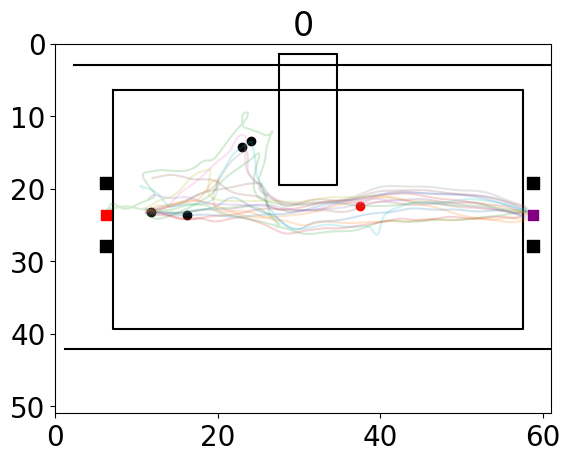

In [394]:
cluster_df = df[(df['obstacle_cluster']==0)&(df['odd']=='left')]


gaze_df = metadata
gaze_timestmps= gaze_df['timestamp'].to_numpy()
fig,ax = plt.subplots()
plot_arena(cluster_df,axis=ax)
plot_orginal_obstacle(cluster_df,axis=ax,cluster=0)
cluster = 0
ax.set_title(str(cluster))
for ind, row in cluster_df.iterrows():
    
    trial_gaze_idx, trial_indx=find_event_frames(row.ts_trial_timestamps,gaze_timestmps)
    if trial_gaze_idx == None:
        ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)
        continue
    else:
        trial_gazes = gaze_df.iloc[trial_gaze_idx]
        cluster_gaze = trial_gazes[trial_gazes.cluster == cluster]
        cluster_gaze_ts = cluster_gaze.timestamp.to_numpy()
        trial_gaze_idx_cluster, trial_indx_cluster=find_event_frames(row.ts_trial_timestamps,cluster_gaze_ts)
        ax.plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm,alpha = .2)

    if cluster_gaze_ts.shape[0] == 0:
        continue
    else:
        for i,cluster_row in enumerate(cluster_gaze.iterrows()):
            if cluster_row[1].movement_direction =='right':
                ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='red')
            else:
                 ax.scatter(row.ts_head_cen_x_cm[trial_indx_cluster[i]],row.ts_head_cen_y_cm[trial_indx_cluster[i]],color='black')

In [366]:
cluster_df

,first_poke,second_poke,trial_timestamps,trial_vidframes,arenaTL_T_x,arenaTL_T_y,arenaTL_T_likelihood,arenaTR_T_x,arenaTR_T_y,arenaTR_T_likelihood,...,obstacle_basis_end_x,obstacle_basis_end_y,goal_head_cen_x,goal_head_cen_y,goal_basis_start_x,goal_basis_start_y,goal_basis_end_x,goal_basis_end_y,obstacle_devations,goal_devations
315,50361.552921,50371.994560,"[50361.569254, 50361.585433, 50361.602124, 503...","[2469, 2470, 2471, 2472, 2473, 2474, 2475, 247...",30.476414,39.948597,"[0.9806698560714722, 0.982363224029541, 0.9885...",847.33905,41.495216,"[0.9970822930335999, 0.9979604482650757, 0.998...",...,34.375715,23.087403,"[34.039345362788424, 33.70022277747802, 33.357...","[22.944046442766716, 22.84409469499215, 22.787...",34.039345,22.944046,7.058491,23.007060,"[nan, 44.918893142687736, 44.835059167192306, ...","[nan, 16.55597456090671, 13.076502197087152, 9..."
317,50378.647065,50389.330444,"[50378.66112, 50378.677811, 50378.694464, 5037...","[3494, 3495, 3496, 3497, 3498, 3499, 3500, 350...",30.476414,39.948597,"[0.9760379791259766, 0.9830150604248047, 0.980...",847.33905,41.495216,"[0.9940181970596313, 0.9936733245849609, 0.995...",...,34.239576,23.503990,"[33.80632651308561, 33.34088926447257, 32.8443...","[23.49694774692357, 23.507897367649694, 23.524...",33.806327,23.496948,7.231819,24.675956,"[nan, 32.609304518414596, 31.325638088929896, ...","[nan, 1.192665705352704, 0.9183572953897001, 1..."
329,50478.893504,50490.637798,"[50478.897356, 50478.914022, 50478.930662, 504...","[9505, 9506, 9507, 9508, 9509, 9510, 9511, 951...",30.476414,39.948597,"[0.977425217628479, 0.9786858558654785, 0.9782...",847.33905,41.495216,"[0.9973878264427185, 0.9981912970542908, 0.996...",...,35.632129,21.907894,"[35.245684573880006, 34.84339435904852, 34.429...","[21.84646845377036, 21.764523515558633, 21.662...",35.245685,21.846468,6.832126,22.398690,"[nan, 52.77597767052117, 51.90865359009344, 50...","[nan, 12.626822774003925, 13.824247134135849, ..."
331,50496.876608,50507.305907,"[50496.890163, 50496.906739, 50496.924044, 504...","[10584, 10585, 10586, 10587, 10588, 10589, 105...",30.476414,39.948597,"[0.9831269979476929, 0.9807167649269104, 0.970...",847.33905,41.495216,"[0.9968408346176147, 0.9946677684783936, 0.993...",...,36.080160,21.885689,"[35.735154099029785, 35.392296878767624, 35.05...","[21.689486058080323, 21.51031617955451, 21.352...",35.735154,21.689486,6.822169,22.181658,"[nan, 14.678065436283264, 14.631504844803931, ...","[nan, 28.56583362284645, 27.254706656773635, 2..."
333,50513.651212,50523.863462,"[50513.665651, 50513.682329, 50513.699008, 505...","[11590, 11591, 11592, 11593, 11594, 11595, 115...",30.476414,39.948597,"[0.9813659191131592, 0.9786948561668396, 0.975...",847.33905,41.495216,"[0.9939407110214233, 0.991999626159668, 0.9954...",...,35.665248,21.935065,"[35.33054966330879, 34.99486580067093, 34.6531...","[21.761279567197622, 21.599038240120244, 21.45...",35.330550,21.761280,7.039485,22.100275,"[nan, 33.27746450979821, 33.903542472499744, 3...","[nan, 26.481722977784422, 25.183449843516478, ..."
335,50528.295718,50536.955635,"[50528.306828, 50528.323417, 50528.340096, 505...","[12468, 12469, 12470, 12471, 12472, 12473, 124...",30.476414,39.948597,"[0.9815084338188171, 0.9859840273857117, 0.978...",847.33905,41.495216,"[0.9903004169464111, 0.9950673580169678, 0.994...",...,36.015408,21.509860,"[35.615894628761595, 35.217829844919436, 34.82...","[21.45590220043507, 21.42812737193654, 21.4197...",35.615895,21.455902,7.154833,22.988818,"[nan, 54.41609546944599, 53.703509032886345, 5...","[nan, 7.074302180961482, 5.686547023119173, 4...."
337,50541.998156,50550.731660,"[50542.013964, 50542.030681, 50542.04736, 5054...","[13290, 13291, 13292, 13293, 13294, 13295, 132...",30.476414,39.948597,"[0.9763855934143066, 0.9759047627449036, 0.977...",847.33905,41.495216,"[0.9938521385192871, 0.9945853352546692, 0.993...",...,35.523585,22.195740,"[35.089989389217976, 34.632996781810704, 34.16...","[22.153269027160846,